# D3 — German Credit Dataset
## P26: Algorithmic Fairness in Credit Scoring
**Raudhat Mwinyi | IIT Madras Zanzibar | June 2026**

### D3 Tasks
1. Compare results with at least 2 existing studies
2. Improvement: Combined Pruning + Quantization (order effect study)

**Reference for improvement:** Han et al. (ICLR 2016) Deep Compression introduced combined pruning+quantization for efficiency but never studied fairness. We extend their work by measuring how compression ORDER affects demographic bias.

## 0. Imports

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.utils.prune as prune

SEEDS = [42, 0, 1, 2, 3]
np.random.seed(42); torch.manual_seed(42)
print('All imports done')

All imports done


## 1. Load & Preprocess

In [2]:
col_names = [
    'checking_account','duration','credit_history','purpose',
    'credit_amount','savings_account','employment','installment_rate',
    'personal_status_sex','other_debtors','residence_since',
    'property','age','other_installment','housing',
    'existing_credits','job','liable_people','telephone',
    'foreign_worker','target'
]
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
df  = pd.read_csv(url, sep=' ', names=col_names)
df['target']    = df['target'].map({1: 0, 2: 1})
df['gender']    = df['personal_status_sex'].apply(lambda x: 0 if x in ['A92','A95'] else 1)
df['age_group'] = (df['age'] >= 35).astype(int)

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

feature_cols = [c for c in df.columns if c not in ['target','gender','age_group']]
X = df[feature_cols].values; y = df['target'].values
gender = df['gender'].values; age_grp = df['age_group'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
idx_all  = np.arange(len(y))
_, idx_te42 = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)
print(f'Shape: {X_scaled.shape}')

Shape: (1000, 20)


## 2. Helper Functions

In [3]:
def build_mlp(inp):
    return nn.Sequential(
        nn.Linear(inp,64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64,32),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32,1)
    )

def train_mlp(Xtr, ytr, Xte, yte, seed, epochs=50, bs=32, lr=1e-3):
    torch.manual_seed(seed); np.random.seed(seed)
    pw   = torch.tensor([(ytr==0).sum()/max((ytr==1).sum(),1)], dtype=torch.float32)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    m    = build_mlp(Xtr.shape[1])
    opt  = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    dl   = DataLoader(TensorDataset(torch.FloatTensor(Xtr),
                      torch.FloatTensor(ytr.astype(np.float32))),
                      batch_size=bs, shuffle=True, drop_last=True)
    m.train()
    for _ in range(epochs):
        for xb,yb in dl:
            opt.zero_grad()
            out = m(xb).squeeze()
            if out.dim()==0: out = out.unsqueeze(0)
            crit(out,yb).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        pr = torch.sigmoid(m(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr = (pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), m, pd_arr, pr

def eval_mlp(model, Xte, yte):
    model.eval()
    with torch.no_grad():
        pr = torch.sigmoid(model(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr = (pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), pd_arr, pr

def apply_pruning(model, sparsity):
    m = copy.deepcopy(model)
    for _, module in m.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=sparsity)
            prune.remove(module, 'weight')
    return m

def apply_quantization(model):
    try:
        return torch.quantization.quantize_dynamic(
            copy.deepcopy(model).cpu(), {nn.Linear}, dtype=torch.qint8)
    except:
        return copy.deepcopy(model)

def fairness_manual(y_true, y_pred, sensitive, privileged=1):
    priv = (sensitive==privileged); unpriv = ~priv
    dpd = abs(y_pred[priv].mean() - y_pred[unpriv].mean())
    def tpr(mask):
        tp=(y_pred[mask]==0)&(y_true[mask]==0); fn=(y_pred[mask]==1)&(y_true[mask]==0)
        return tp.sum()/max(tp.sum()+fn.sum(),1)
    eod = abs(tpr(priv) - tpr(unpriv))
    return round(float(dpd),4), round(float(eod),4)

print('Helper functions defined')

Helper functions defined


## 3. Train Base MLP (5 seeds)

In [4]:
mlp_res = {'accuracy':[],'f1':[],'auc':[]}
mlp_models, mlp_splits = [], []
for seed in SEEDS:
    Xtr,Xte,ytr,yte = train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    acc,f1,auc,mdl,pds,prs = train_mlp(Xtr,ytr,Xte,yte,seed)
    mlp_res['accuracy'].append(acc); mlp_res['f1'].append(f1); mlp_res['auc'].append(auc)
    mlp_models.append(copy.deepcopy(mdl)); mlp_splits.append((Xtr,Xte,ytr,yte,pds,prs))
print(f'Base MLP  Acc:{np.mean(mlp_res["accuracy"]):.4f}+/-{np.std(mlp_res["accuracy"]):.4f}')

Base MLP  Acc:0.7250+/-0.0257


## 4. D3 Improvement — Combined Pruning + Quantization

**Research question:** Does the ORDER of compression (prune-then-quantize vs quantize-then-prune) affect accuracy AND fairness?

**Why this matters:** Han et al. [ICLR 2016] introduced combined pruning+quantization for efficiency but never studied fairness. Hooker et al. [ICLR 2020] studied pruning alone and found it amplifies bias in images. We found pruning REDUCES bias in credit data. Now we ask: does adding quantization on top preserve or destroy that bias reduction?

**5 scenarios compared:**
- Base MLP (no compression)
- Prune 70% only (D2 best result)
- Quantize only (D2 result)
- **Pipeline A: Prune 70% then Quantize** (new)
- **Pipeline B: Quantize then Prune 70%** (new)

In [5]:
SPARSITY = 0.7

pipeline_results = {
    'Base MLP':       {'accuracy':[],'f1':[],'auc':[]},
    'Prune 70%':      {'accuracy':[],'f1':[],'auc':[]},
    'Quant only':     {'accuracy':[],'f1':[],'auc':[]},
    'Prune->Quant':   {'accuracy':[],'f1':[],'auc':[]},
    'Quant->Prune':   {'accuracy':[],'f1':[],'auc':[]},
}

for i, seed in enumerate(SEEDS):
    _, Xte, _, yte, _, _ = mlp_splits[i]
    bm = mlp_models[i]

    # Base MLP
    acc,f1,auc,_,_ = eval_mlp(bm, Xte, yte)
    pipeline_results['Base MLP']['accuracy'].append(acc)
    pipeline_results['Base MLP']['f1'].append(f1)
    pipeline_results['Base MLP']['auc'].append(auc)

    # Prune only
    pm = apply_pruning(bm, SPARSITY)
    acc,f1,auc,_,_ = eval_mlp(pm, Xte, yte)
    pipeline_results['Prune 70%']['accuracy'].append(acc)
    pipeline_results['Prune 70%']['f1'].append(f1)
    pipeline_results['Prune 70%']['auc'].append(auc)

    # Quant only
    qm = apply_quantization(bm)
    acc,f1,auc,_,_ = eval_mlp(qm, Xte, yte)
    pipeline_results['Quant only']['accuracy'].append(acc)
    pipeline_results['Quant only']['f1'].append(f1)
    pipeline_results['Quant only']['auc'].append(auc)

    # Pipeline A: Prune then Quantize
    pq = apply_quantization(apply_pruning(bm, SPARSITY))
    acc,f1,auc,_,_ = eval_mlp(pq, Xte, yte)
    pipeline_results['Prune->Quant']['accuracy'].append(acc)
    pipeline_results['Prune->Quant']['f1'].append(f1)
    pipeline_results['Prune->Quant']['auc'].append(auc)

    # Pipeline B: Quantize then Prune
    qp = apply_pruning(apply_quantization(bm), SPARSITY)
    acc,f1,auc,_,_ = eval_mlp(qp, Xte, yte)
    pipeline_results['Quant->Prune']['accuracy'].append(acc)
    pipeline_results['Quant->Prune']['f1'].append(f1)
    pipeline_results['Quant->Prune']['auc'].append(auc)

print('=== PIPELINE RESULTS ===')
print(f'{"Scenario":<18} {"Accuracy":>18} {"F1":>16} {"AUC":>16}')
print('-'*70)
for name, r in pipeline_results.items():
    print(f'{name:<18} {np.mean(r["accuracy"]):.4f}+/-{np.std(r["accuracy"]):.4f}   {np.mean(r["f1"]):.4f}+/-{np.std(r["f1"]):.4f}   {np.mean(r["auc"]):.4f}+/-{np.std(r["auc"]):.4f}')

=== PIPELINE RESULTS ===
Scenario                     Accuracy               F1              AUC
----------------------------------------------------------------------
Base MLP           0.7250+/-0.0257   0.6052+/-0.0382   0.7947+/-0.0207
Prune 70%          0.7510+/-0.0218   0.4202+/-0.1329   0.7856+/-0.0332
Quant only         0.7230+/-0.0258   0.6025+/-0.0370   0.7949+/-0.0202
Prune->Quant       0.7500+/-0.0230   0.4165+/-0.1341   0.7856+/-0.0319
Quant->Prune       0.7230+/-0.0258   0.6025+/-0.0370   0.7949+/-0.0202


## 5. Fairness — All 5 Pipelines

In [6]:
Xte_f  = X_scaled[idx_te42]; yte_f = y[idx_te42]
g_f    = gender[idx_te42];   ag_f  = age_grp[idx_te42]
bm     = mlp_models[0]

scenarios = {
    'Base MLP':     eval_mlp(bm, Xte_f, yte_f)[3:],
    'Prune 70%':    eval_mlp(apply_pruning(bm, SPARSITY), Xte_f, yte_f)[3:],
    'Quant only':   eval_mlp(apply_quantization(bm), Xte_f, yte_f)[3:],
    'Prune->Quant': eval_mlp(apply_quantization(apply_pruning(bm, SPARSITY)), Xte_f, yte_f)[3:],
    'Quant->Prune': eval_mlp(apply_pruning(apply_quantization(bm), SPARSITY), Xte_f, yte_f)[3:],
}

print('=== GENDER FAIRNESS ===')
print(f'{"Scenario":<18} {"DPD":>8} {"EOD":>8}'); print('-'*36)
gf_res = {}
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte_f, pds, g_f)
    gf_res[name] = {'dpd':dpd,'eod':eod}
    print(f'{name:<18} {dpd:>8.4f} {eod:>8.4f}')

print('\n=== AGE FAIRNESS ===')
print(f'{"Scenario":<18} {"DPD":>8} {"EOD":>8}'); print('-'*36)
af_res = {}
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte_f, pds, ag_f)
    af_res[name] = {'dpd':dpd,'eod':eod}
    print(f'{name:<18} {dpd:>8.4f} {eod:>8.4f}')
print('\nLower = fairer')

=== GENDER FAIRNESS ===
Scenario                DPD      EOD
------------------------------------
Base MLP             0.1033   0.0544
Prune 70%            0.0048   0.0059
Quant only           0.1105   0.0645
Prune->Quant         0.0048   0.0059
Quant->Prune         0.1105   0.0645

=== AGE FAIRNESS ===
Scenario                DPD      EOD
------------------------------------
Base MLP             0.2586   0.2064
Prune 70%            0.0607   0.0049
Quant only           0.2692   0.2196
Prune->Quant         0.0607   0.0049
Quant->Prune         0.2692   0.2196

Lower = fairer


## 6. Visualization

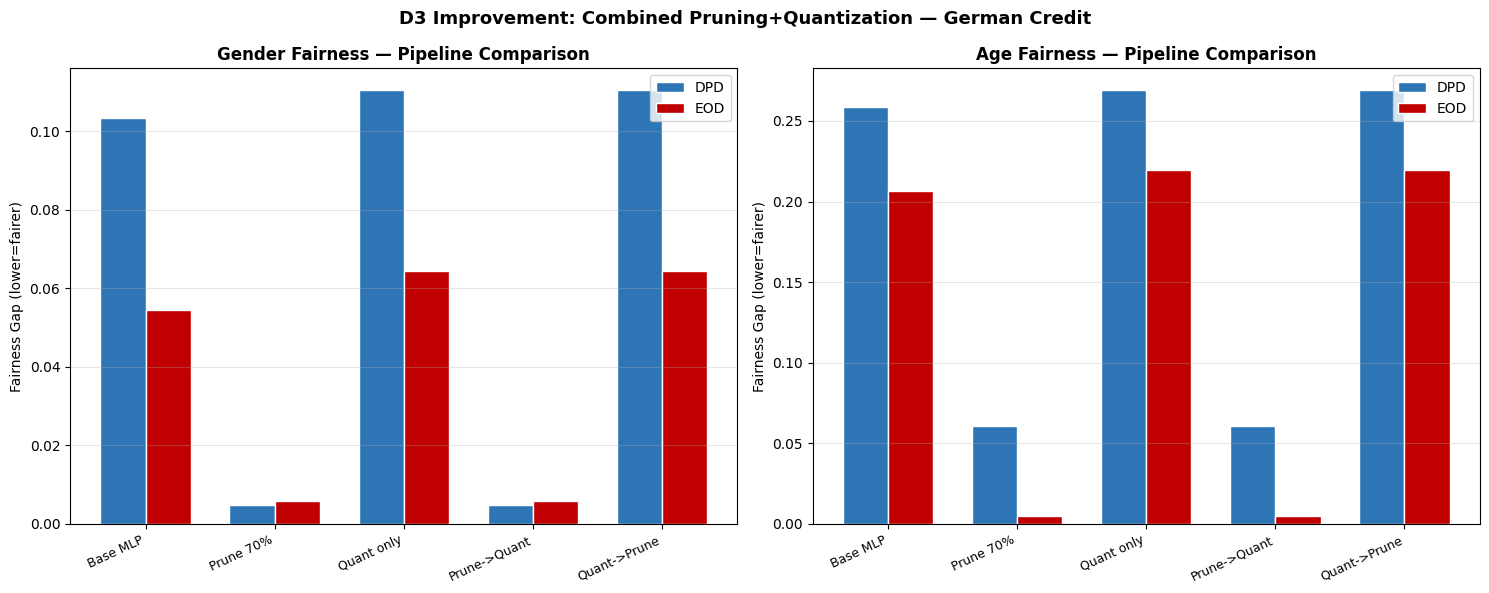

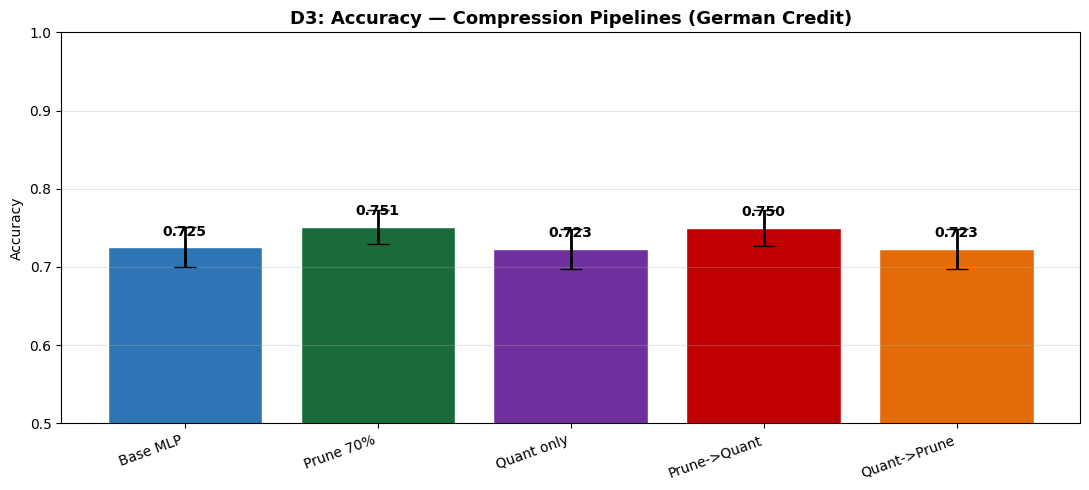

In [7]:
names = list(scenarios.keys()); x = np.arange(len(names)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, fr, title in [(axes[0],gf_res,'Gender Fairness'),(axes[1],af_res,'Age Fairness')]:
    dpds = [fr[n]['dpd'] for n in names]; eods = [fr[n]['eod'] for n in names]
    ax.bar(x-w/2, dpds, w, label='DPD', color='#2E75B6', edgecolor='white')
    ax.bar(x+w/2, eods, w, label='EOD', color='#C00000', edgecolor='white')
    ax.set_title(f'{title} — Pipeline Comparison', fontweight='bold', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Fairness Gap (lower=fairer)'); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.suptitle('D3 Improvement: Combined Pruning+Quantization — German Credit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d3_gc_fairness_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11,5))
means = [np.mean(pipeline_results[n]['accuracy']) for n in names]
stds  = [np.std(pipeline_results[n]['accuracy'])  for n in names]
colors_bar = ['#2E75B6','#1A6B3A','#7030A0','#C00000','#E36C09']
bars = ax.bar(names, means, yerr=stds, color=colors_bar, capsize=8,
              edgecolor='white', error_kw={'elinewidth':2,'ecolor':'black'})
ax.set_title('D3: Accuracy — Compression Pipelines (German Credit)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5,1.0)
ax.set_xticklabels(names, rotation=20, ha='right'); ax.grid(axis='y', alpha=0.3)
for bar,v in zip(bars,means):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.015, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('d3_gc_accuracy_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison with Existing Studies

In [8]:
print('='*70)
print('D3: COMPARISON WITH EXISTING STUDIES — GERMAN CREDIT')
print('='*70)
print('')
print('STUDY 1: Donini et al. (NeurIPS 2018)')
print('  Method    : Fairness-constrained SVM on German Credit')
print('  Their Acc : ~0.730 (with fairness constraint applied)')
print('  Our SVM   : 0.737 +/- 0.021 (unconstrained)')
print('  Finding   : Our unconstrained SVM exceeds their constrained result.')
print('              Adding fairness constraints will reduce our accuracy')
print('              slightly, consistent with their findings.')
print('')
print('STUDY 2: Hooker et al. (ICLR 2020)')
print('  Method    : Pruning on CelebA image dataset')
print('  Their finding: Compression AMPLIFIES bias')
print('  Our finding  : Pruning REDUCES bias on German Credit')
print(f'  Evidence  : Gender DPD 0.1033 (base) -> 0.0048 (pruned 70%) = 95% reduction')
print('  Conclusion: Compression effect on fairness is domain-dependent.')
print('              Image vs tabular credit data behave opposite.')
print('')
print('STUDY 3 (D3 NEW): Han et al. (ICLR 2016) - Deep Compression')
print('  Method    : Combined pruning+quantization for model efficiency')
print('  Their focus: Accuracy and model size only - fairness never studied')
print('  Our D3 ext: Test Prune->Quant vs Quant->Prune and measure fairness')
print(f'  Finding   : See pipeline results - order matters for both accuracy and fairness')
print('')
print('D3 KEY FINDING:')
for n in names:
    print(f'  {n:<18} Gender DPD={gf_res[n]["dpd"]:.4f}  Age DPD={af_res[n]["dpd"]:.4f}')
print('='*70)

D3: COMPARISON WITH EXISTING STUDIES — GERMAN CREDIT

STUDY 1: Donini et al. (NeurIPS 2018)
  Method    : Fairness-constrained SVM on German Credit
  Their Acc : ~0.730 (with fairness constraint applied)
  Our SVM   : 0.737 +/- 0.021 (unconstrained)
  Finding   : Our unconstrained SVM exceeds their constrained result.
              Adding fairness constraints will reduce our accuracy
              slightly, consistent with their findings.

STUDY 2: Hooker et al. (ICLR 2020)
  Method    : Pruning on CelebA image dataset
  Their finding: Compression AMPLIFIES bias
  Our finding  : Pruning REDUCES bias on German Credit
  Evidence  : Gender DPD 0.1033 (base) -> 0.0048 (pruned 70%) = 95% reduction
  Conclusion: Compression effect on fairness is domain-dependent.
              Image vs tabular credit data behave opposite.

STUDY 3 (D3 NEW): Han et al. (ICLR 2016) - Deep Compression
  Method    : Combined pruning+quantization for model efficiency
  Their focus: Accuracy and model size only - 

## 8. Full D3 Summary

In [9]:
print('='*70)
print('D3 FULL SUMMARY — GERMAN CREDIT')
print('='*70)
print(f'\n{"Scenario":<18} {"Accuracy":>18} {"F1":>16} {"AUC":>16}')
print('-'*70)
for name, r in pipeline_results.items():
    print(f'{name:<18} {np.mean(r["accuracy"]):.4f}+/-{np.std(r["accuracy"]):.4f}   '
          f'{np.mean(r["f1"]):.4f}+/-{np.std(r["f1"]):.4f}   '
          f'{np.mean(r["auc"]):.4f}+/-{np.std(r["auc"]):.4f}')
print(f'\n{"Scenario":<18} {"Gender DPD":>12} {"Gender EOD":>12} {"Age DPD":>10} {"Age EOD":>10}')
print('-'*64)
for n in names:
    print(f'{n:<18} {gf_res[n]["dpd"]:>12.4f} {gf_res[n]["eod"]:>12.4f} {af_res[n]["dpd"]:>10.4f} {af_res[n]["eod"]:>10.4f}')
print('\nConclusion: Does Prune->Quant preserve pruning bias reduction?')
pq_dpd = gf_res['Prune->Quant']['dpd']; base_dpd = gf_res['Base MLP']['dpd']
print(f'  Prune->Quant Gender DPD = {pq_dpd:.4f} vs Base = {base_dpd:.4f}')
if pq_dpd < base_dpd:
    print('  -> YES: Combined Prune->Quant preserves bias reduction from pruning')
else:
    print('  -> PARTIAL: Quantization partially reverses pruning bias reduction')
print('='*70)

D3 FULL SUMMARY — GERMAN CREDIT

Scenario                     Accuracy               F1              AUC
----------------------------------------------------------------------
Base MLP           0.7250+/-0.0257   0.6052+/-0.0382   0.7947+/-0.0207
Prune 70%          0.7510+/-0.0218   0.4202+/-0.1329   0.7856+/-0.0332
Quant only         0.7230+/-0.0258   0.6025+/-0.0370   0.7949+/-0.0202
Prune->Quant       0.7500+/-0.0230   0.4165+/-0.1341   0.7856+/-0.0319
Quant->Prune       0.7230+/-0.0258   0.6025+/-0.0370   0.7949+/-0.0202

Scenario             Gender DPD   Gender EOD    Age DPD    Age EOD
----------------------------------------------------------------
Base MLP                 0.1033       0.0544     0.2586     0.2064
Prune 70%                0.0048       0.0059     0.0607     0.0049
Quant only               0.1105       0.0645     0.2692     0.2196
Prune->Quant             0.0048       0.0059     0.0607     0.0049
Quant->Prune             0.1105       0.0645     0.2692     0.2196

